# Notebook 01: Activation Patching

**Goal:** Find *where* inside GPT-2 small the induction behavior lives.

**Method:**
1. Run the model on **clean** tokens (repeated sequence) → strong induction (logit_diff ~21)
2. Run the model on **corrupted** tokens (first half messed up) → induction breaks
3. For each (layer, position), swap in the clean activation → measure how much induction recovers
4. Plot a heatmap of recovery

If a location lights up, it means: "the information flowing through this (layer, position) is causally necessary for induction."

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer

from src.data import make_induction_tokens
from src.metrics import induction_positions_and_targets, logit_diff
from src.corruptions import corrupt_prefix_random_replace
from src.patching import compute_patching_heatmap
from src.plotting import plot_patching_heatmap

## Step 1: Setup (same model + data as notebook 00)

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = HookedTransformer.from_pretrained('gpt2-small', device=device)

N_CTX_HALF = 50
BATCH = 30

tokens = make_induction_tokens(
    batch=BATCH,
    n_ctx_half=N_CTX_HALF,
    bos_token_id=model.tokenizer.bos_token_id,
    seed=42,
).to(device)

print(f'Device: {device}, GPU: {torch.cuda.get_device_name(0)}')
print(f'Token shape: {tokens.shape}')

## Step 2: Create corrupted tokens

We corrupt 100% of the first half (eps=1.0) — replace every token with a random one.

Why 100%? We want maximum corruption so the gap between clean and corrupted
is large. This makes the patching signal easier to see. Later (notebook 02)
we'll sweep over different corruption rates.

**Important:** only the first half is corrupted. The second half still has the
original tokens. But since the first half no longer matches, the model can't
use its "look back and copy" strategy.

In [3]:
corrupted_tokens = corrupt_prefix_random_replace(
    tokens.cpu(), n_ctx_half=N_CTX_HALF, eps=1.0, seed=123
).to(device)

# Verify: first half is different, second half is the same
first_half_match = torch.equal(tokens[:, 1:N_CTX_HALF+1], corrupted_tokens[:, 1:N_CTX_HALF+1])
second_half_match = torch.equal(tokens[:, N_CTX_HALF+1:], corrupted_tokens[:, N_CTX_HALF+1:])
print(f'First half matches (should be False): {first_half_match}')
print(f'Second half matches (should be True): {second_half_match}')

First half matches (should be False): False
Second half matches (should be True): True


## Step 3: Verify corruption breaks induction

Quick sanity check: the logit_diff should be much lower on corrupted tokens.

In [4]:
eval_positions, eval_targets = induction_positions_and_targets(tokens.cpu(), N_CTX_HALF)
eval_positions = eval_positions.to(device)
eval_targets = eval_targets.to(device)

with torch.no_grad():
    clean_logits = model(tokens)
    corrupted_logits = model(corrupted_tokens)

clean_ld = logit_diff(clean_logits, eval_positions, eval_targets)
corrupted_ld = logit_diff(corrupted_logits, eval_positions, eval_targets)

print(f'Clean logit diff:     {clean_ld.item():.3f}')
print(f'Corrupted logit diff: {corrupted_ld.item():.3f}')
print(f'Drop: {clean_ld.item() - corrupted_ld.item():.3f}')

Clean logit diff:     21.541
Corrupted logit diff: 0.065
Drop: 21.476


## Step 4: Run activation patching

This is the main experiment. For every (layer, position) in the model,
we patch the clean residual stream activation into the corrupted run
and measure recovery.

This will take a few minutes (12 layers × 101 positions = 1212 forward passes).

**What to watch for in the output:**
- Early layers should show recovery at first-half positions (that's where the model encodes "what tokens are in my context")
- Middle/later layers should show recovery at second-half positions (that's where the induction heads read the info and make predictions)

In [5]:
# Build metric function that our patching code can call
def metric_fn(logits):
    return logit_diff(logits, eval_positions, eval_targets)

heatmap, clean_val, corrupted_val = compute_patching_heatmap(
    model, tokens, corrupted_tokens, metric_fn
)

# Save for later use
torch.save(heatmap, '../results/cache/patching_heatmap.pt')
print(f'\nHeatmap shape: {heatmap.shape}')
print(f'Max recovery: {heatmap.max():.3f}')
print(f'Where: layer {heatmap.max(dim=1).values.argmax()}, position {heatmap.max(dim=0).values.argmax()}')

Clean metric:     21.541
Corrupted metric: 0.065
Gap to recover:   21.476

Patching 12 layers x 101 positions...
  Layer  0 done — max recovery: 0.001
  Layer  1 done — max recovery: 0.001
  Layer  2 done — max recovery: 0.001
  Layer  3 done — max recovery: 0.001
  Layer  4 done — max recovery: 0.004
  Layer  5 done — max recovery: 0.008
  Layer  6 done — max recovery: 0.005
  Layer  7 done — max recovery: 0.006
  Layer  8 done — max recovery: 0.012
  Layer  9 done — max recovery: 0.015
  Layer 10 done — max recovery: 0.022
  Layer 11 done — max recovery: 0.023

Heatmap shape: torch.Size([12, 101])
Max recovery: 0.023
Where: layer 11, position 81


## Step 5: Plot the heatmap

This is Figure 2 of our project.

**How to read it:**
- x-axis: token position (left of black dashed line = first half, right = second half)
- y-axis: layer (0 = bottom/earliest, 11 = top/latest)
- Color: red = patching here recovers induction, blue = patching here hurts, white = no effect

You should see a pattern: information flows from the first half in early layers
to the second half in later layers. That flow IS the induction circuit.

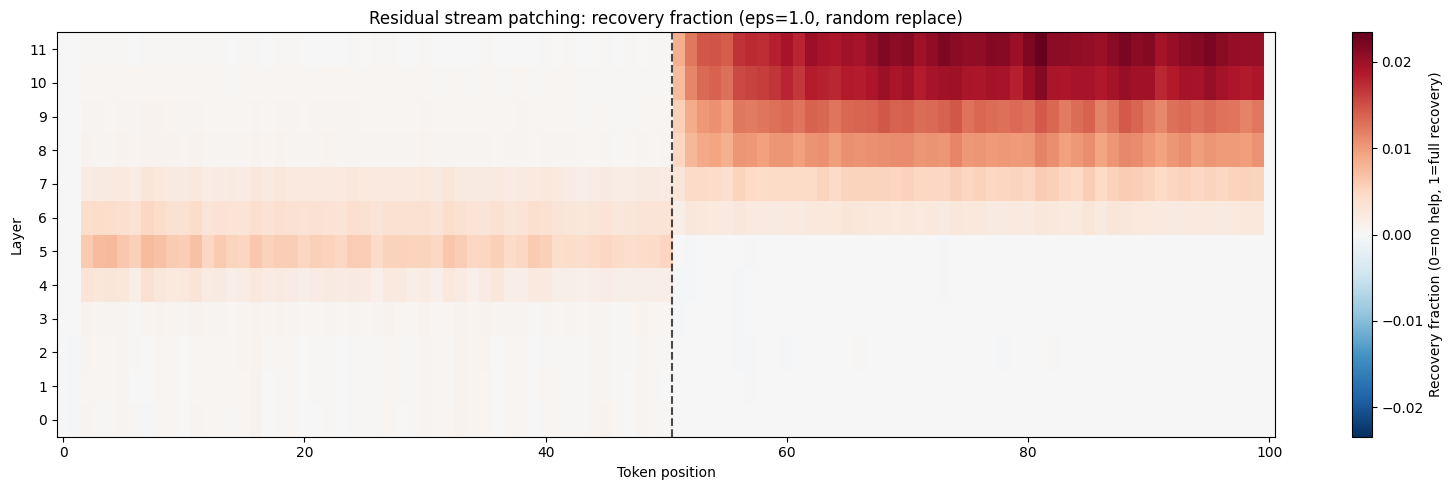

In [6]:
plot_patching_heatmap(
    heatmap,
    n_ctx_half=N_CTX_HALF,
    title='Residual stream patching: recovery fraction (eps=1.0, random replace)',
    save_path='../results/figures/fig2_patching_heatmap.png',
)

## Step 6: Summarize — which layers matter most?

Average recovery across positions for each layer to see which layers
carry the most induction-relevant information.

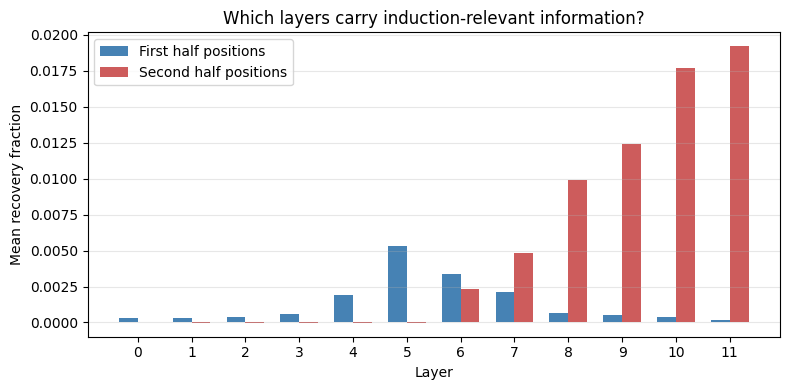

In [7]:
# Average recovery per layer, separately for first-half and second-half positions
first_half_recovery = heatmap[:, 1:N_CTX_HALF+1].mean(dim=1)   # skip BOS
second_half_recovery = heatmap[:, N_CTX_HALF+1:].mean(dim=1)

fig, ax = plt.subplots(figsize=(8, 4))
layers = np.arange(model.cfg.n_layers)
width = 0.35
ax.bar(layers - width/2, first_half_recovery.numpy(), width, label='First half positions', color='steelblue')
ax.bar(layers + width/2, second_half_recovery.numpy(), width, label='Second half positions', color='indianred')
ax.set_xlabel('Layer')
ax.set_ylabel('Mean recovery fraction')
ax.set_title('Which layers carry induction-relevant information?')
ax.legend()
ax.set_xticks(layers)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../results/figures/fig2b_layer_recovery.png', dpi=150)
plt.show()

## What we learned from position-level patching

The max recovery was only ~2.3%. This makes sense: induction relies on
info from ALL first-half positions. Patching one position restores 1/50
of the information ≈ 2%.

**Lesson:** the granularity of your intervention matters. Position-level
patching is too fine-grained here. Let's try **head-level patching** instead:
patch an entire attention head's output (all positions at once) and see which
heads drive induction.

In [8]:
from src.patching import compute_head_patching_heatmap
from src.plotting import plot_head_patching_heatmap

head_heatmap, _, _ = compute_head_patching_heatmap(
    model, tokens, corrupted_tokens, metric_fn
)

torch.save(head_heatmap, '../results/cache/head_patching_heatmap.pt')
print(f'\nHead heatmap shape: {head_heatmap.shape}')

# Find top 5 heads
flat_idx = head_heatmap.flatten().argsort(descending=True)[:5]
for idx in flat_idx:
    layer = idx.item() // model.cfg.n_heads
    head = idx.item() % model.cfg.n_heads
    print(f'  Layer {layer}, Head {head}: recovery = {head_heatmap[layer, head]:.3f}')

Cache check OK. hook_z shape: torch.Size([30, 101, 12, 64])
Clean metric:     21.541
Corrupted metric: 0.065
Gap to recover:   21.476

Patching 12 layers x 12 heads = 144 runs...
  Layer  0 done — best head: 6 (recovery: 0.001)
  Layer  1 done — best head: 6 (recovery: 0.001)
  Layer  2 done — best head: 1 (recovery: 0.001)
  Layer  3 done — best head: 7 (recovery: 0.000)
  Layer  4 done — best head: 11 (recovery: 0.000)
  Layer  5 done — best head: 1 (recovery: 0.054)
  Layer  6 done — best head: 9 (recovery: 0.062)
  Layer  7 done — best head: 2 (recovery: 0.074)
  Layer  8 done — best head: 1 (recovery: 0.022)
  Layer  9 done — best head: 9 (recovery: 0.061)
  Layer 10 done — best head: 0 (recovery: 0.048)
  Layer 11 done — best head: 9 (recovery: 0.035)

Head heatmap shape: torch.Size([12, 12])
  Layer 7, Head 2: recovery = 0.074
  Layer 6, Head 9: recovery = 0.062
  Layer 9, Head 9: recovery = 0.061
  Layer 9, Head 6: recovery = 0.061
  Layer 5, Head 1: recovery = 0.054


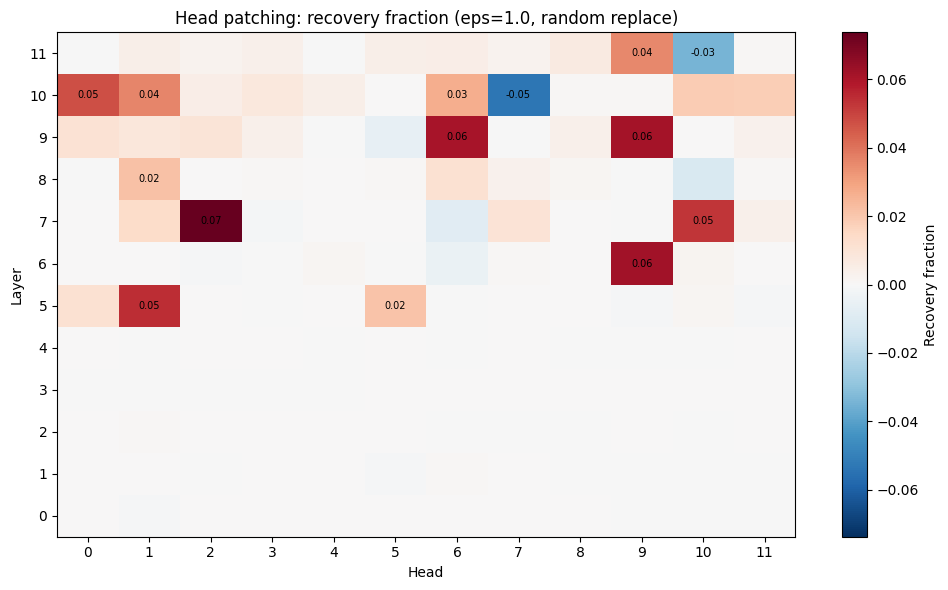

In [9]:
plot_head_patching_heatmap(
    head_heatmap,
    title='Head patching: recovery fraction (eps=1.0, random replace)',
    save_path='../results/figures/fig2c_head_patching_heatmap.png',
)

## What we learned

1. **Position-level patching** showed that induction info is distributed — no single position is a bottleneck
2. **Head-level patching** reveals which specific attention heads implement induction
3. The heads with high recovery are our "induction heads" — they're the ones doing the "look back and copy" work

**Next step (Notebook 02):** Validate these heads with ablation (disable them and show induction breaks), then run our erasure sweep to see how the circuit behaves under varying corruption.